I'll use this script to draw summary graphs
1) TAT for different workloads for a given capacity.
2) Sensitivity analysis
3) Resilience analysis


In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


In [15]:
RESULTS_DIR = r'/Users/varad/Desktop/Lenovo Desktop/Oxford/DPhil Cervical Cancer Scale-up/Code/real_world_sim/Final_Results'

df_experiments = pd.read_csv(f'{RESULTS_DIR}/Cleaned_data_for_analysis.csv')
df_res_util = pd.read_csv(f'{RESULTS_DIR}/Res_util_data.csv')

# CSV headers and blank/inf fields are padded with spaces — normalise once.
df_experiments.columns = [c.strip() for c in df_experiments.columns]
df_res_util.columns = [c.strip() for c in df_res_util.columns]

NUMERIC_COLS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "Recovery Days"]
for col in NUMERIC_COLS:
    if col not in df_experiments.columns:
        continue
    if df_experiments[col].dtype == object:
        df_experiments[col] = (
            df_experiments[col].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
        )
    df_experiments[col] = pd.to_numeric(df_experiments[col], errors="coerce")

LABEL_COL = df_experiments.columns[0]
df_experiments.head()


,Scenario Name - Increasing Demand,,count,mean,std,min,25%,50%,75%,max,Recovery Days
0,Baseline - 5 pap per day ...,,2193.0,1.185,0.565,0.054,0.868,1.005,1.739,3.086,NaN
1,1.5x Demand - 8 pap per day ...,,3282.0,1.234,0.566,0.049,0.887,1.019,1.781,4.006,NaN
2,2x Demand - 10 pap per day ...,,3909.0,1.315,0.593,0.044,0.912,1.046,1.837,4.728,NaN
3,2.5x Demand - 13 pap per day ...,,5113.0,1.423,0.580,0.068,0.950,1.089,1.869,4.003,NaN
4,3x Demand - 15 pap per day ...,,5758.0,1.539,0.588,0.076,1.004,1.777,1.913,4.726,NaN


## Helpers

Shared helpers used by the TAT box plots, utilisation heatmaps, and resilience bars.


In [16]:
def split_experiments(df, label_col=None):
    """Split the stacked CSV into (title, block) pairs.

    Header rows have an empty / NaN `count`. The first block is titled by the
    first column header; later blocks take their title from the header row.
    """
    label_col = label_col or df.columns[0]
    experiments = []
    current_title = label_col
    current_rows = []

    for _, row in df.iterrows():
        label = str(row[label_col]).strip()
        if pd.isna(row["count"]):
            if current_rows:
                experiments.append((current_title, pd.DataFrame(current_rows)))
                current_rows = []
            if label and label.lower() != "nan":
                current_title = label
            continue
        current_rows.append(row)

    if current_rows:
        experiments.append((current_title, pd.DataFrame(current_rows)))
    return experiments


def build_box_stats(block, label_col=None):
    """Build matplotlib bxp stats from precomputed quartiles."""
    label_col = label_col or block.columns[0]
    return [
        {
            "label": str(row[label_col]).strip(),
            "whislo": row["min"],
            "q1": row["25%"],
            "med": row["50%"],
            "q3": row["75%"],
            "whishi": row["max"],
            "mean": row["mean"],
            "fliers": [],
        }
        for _, row in block.iterrows()
    ]


def tat_threshold(title):
    """7-day target for cytology, 14-day for histopathology."""
    is_histo = any(k in title.lower() for k in ["histo", "biops", "tissue"])
    return 14 if is_histo else 7


def plot_tat_boxplot(title, block, ax=None, figsize=(11, 6)):
    """Draw a TAT box plot from summary stats; return (fig, ax)."""
    box_stats = build_box_stats(block)
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.bxp(
        box_stats,
        showmeans=False,
        patch_artist=True,
        boxprops=dict(facecolor="#4C72B0", alpha=0.6),
        medianprops=dict(color="black"),
    )
    threshold = tat_threshold(title)
    ax.axhline(
        threshold,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"{threshold}-day threshold",
    )
    ax.legend(loc="upper left")
    ax.set_ylabel("Turnaround time (days)", fontsize=15)
    ax.set_title(f"{title} – TAT Distribution", fontsize=16)
    ax.set_xticks(range(1, len(box_stats) + 1))
    ax.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if created:
        plt.tight_layout()
    return fig, ax, box_stats


def format_recovery(v):
    if pd.isna(v):
        return ""
    if np.isinf(v):
        return "∞"
    return f"{v:.0f}" if abs(v - round(v)) < 1e-6 else f"{v:.1f}"


experiments = split_experiments(df_experiments, LABEL_COL)
print(f"Parsed {len(experiments)} experiment blocks:")
for title, block in experiments:
    n_rec = block["Recovery Days"].notna().sum()
    print(f"  - {title} ({len(block)} scenarios, {n_rec} with recovery days)")


Parsed 7 experiment blocks:
  - Scenario Name - Increasing Demand (7 scenarios, 0 with recovery days)
  - Resilience metric - JR Patho Strike with increasing demand - Cyto (7 scenarios, 6 with recovery days)
  - Sensitivity Analysis Cyto Service Times JR Pathologist (4 scenarios, 0 with recovery days)
  - Sensitivity Analysis Histo Sample Size Ratios (7 scenarios, 0 with recovery days)
  - Scenario Name - Increasing demand - Histopathology (7 scenarios, 0 with recovery days)
  - Scenario Name - Resilience with increasing demand JR Patho srtike 6 days- Histopath (7 scenarios, 6 with recovery days)
  - Scenario Name - Resilience with increasing demand Tissue Processing equipment breakdown (7 scenarios, 3 with recovery days)


## Experiment 1: Increasing Demand (Cytology)

Box plots of turnaround time (TAT) across all increasing-demand scenarios
(every row up to the next experiment). Boxes are built from the precomputed
quartiles (`min`, `25%`, `50%`, `75%`, `max`) using `Axes.bxp`.


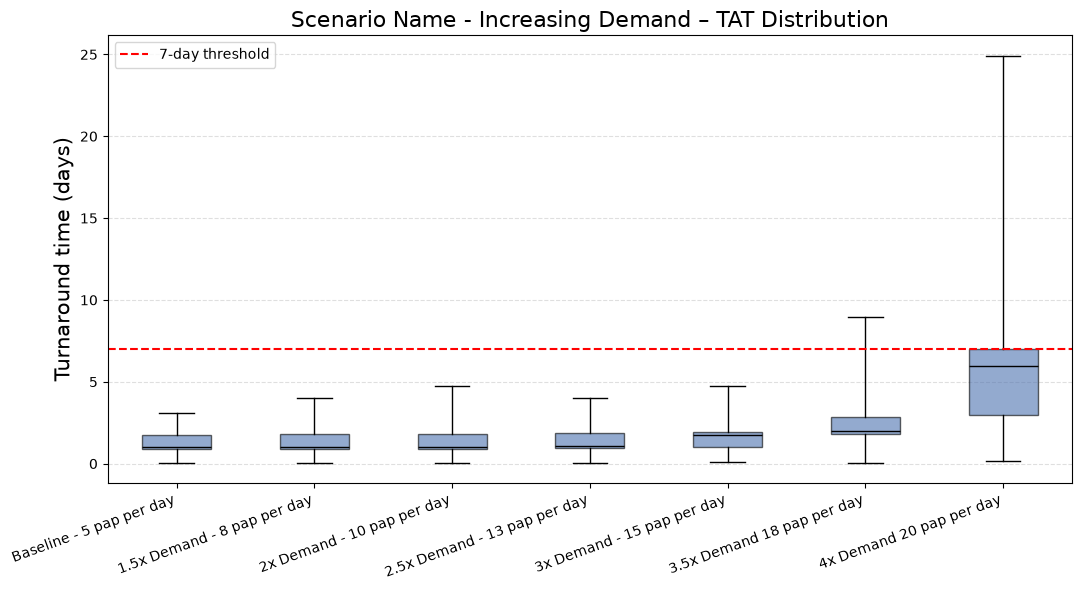

In [17]:
# First experiment block = Increasing Demand (Cytology)
title, demand = experiments[0]
plot_tat_boxplot(title, demand, figsize=(11, 6))
plt.show()


## All Experiments

TAT box plot for every experiment block. Cytology uses a 7-day threshold;
histopathology uses 14 days.


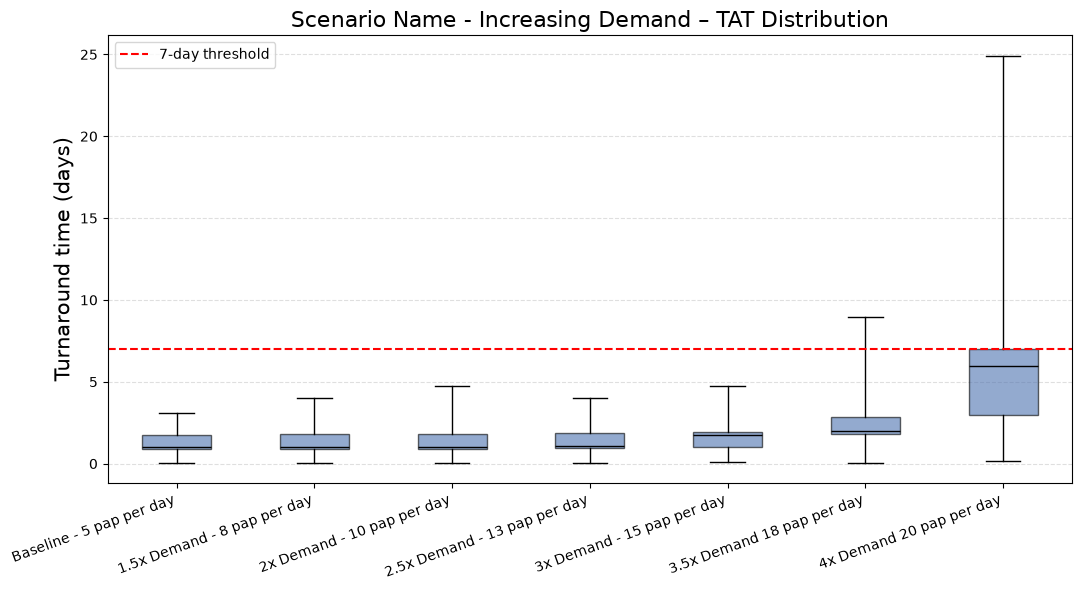

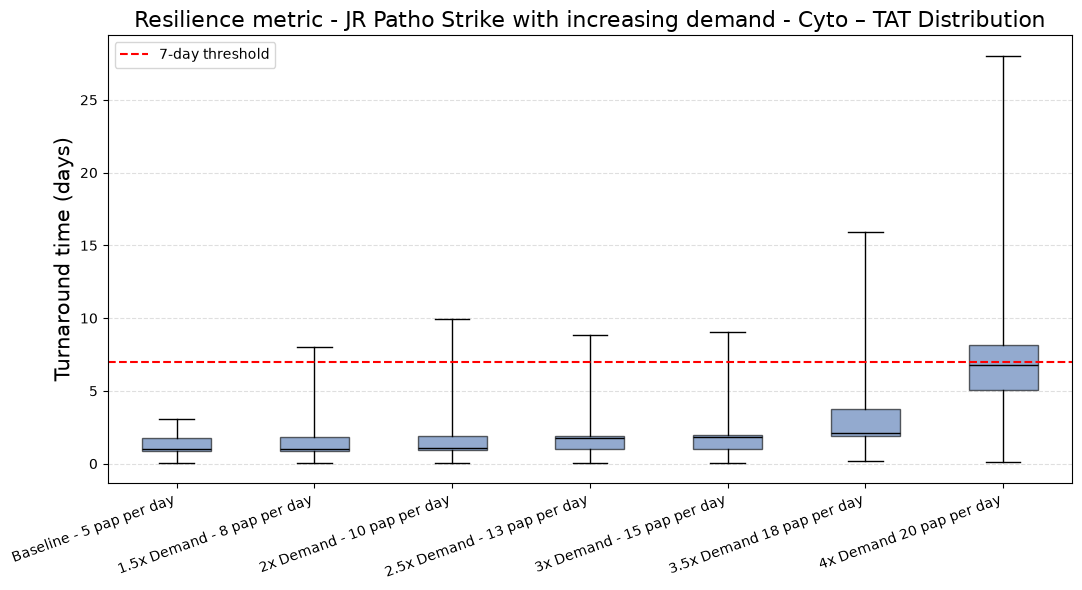

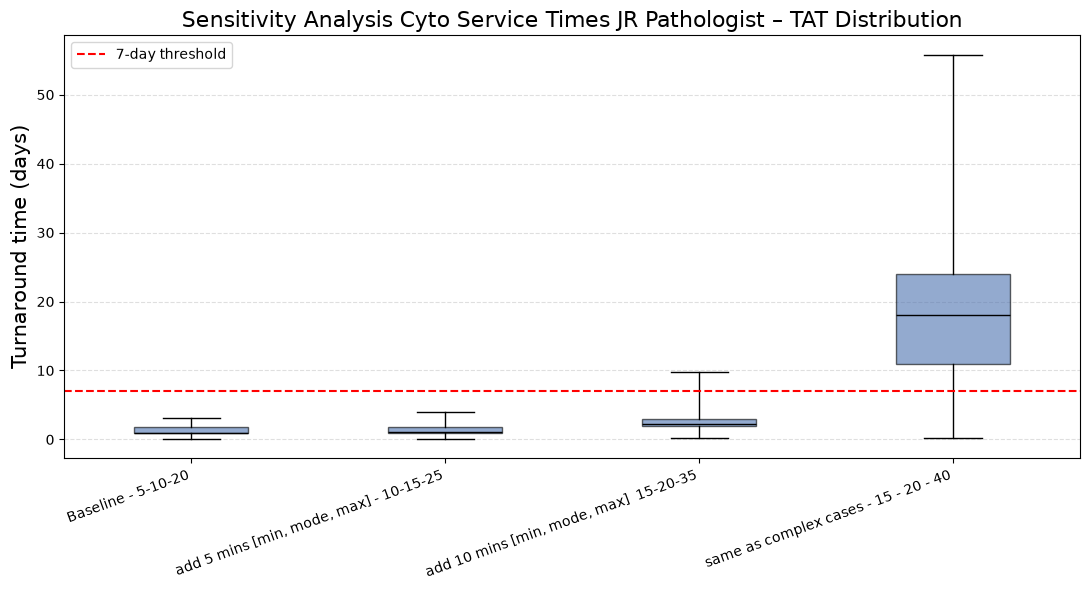

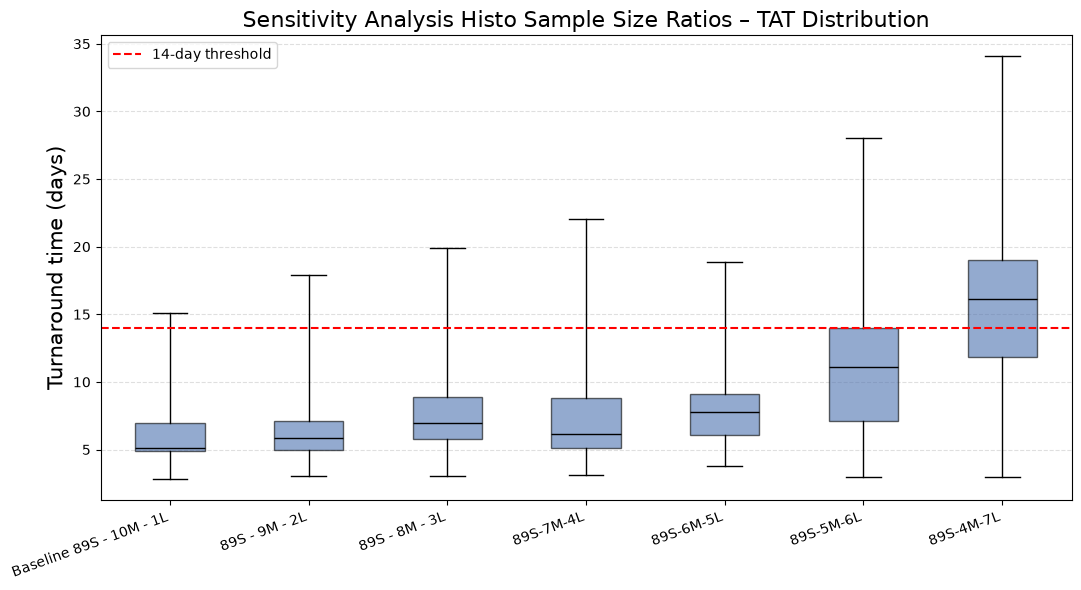

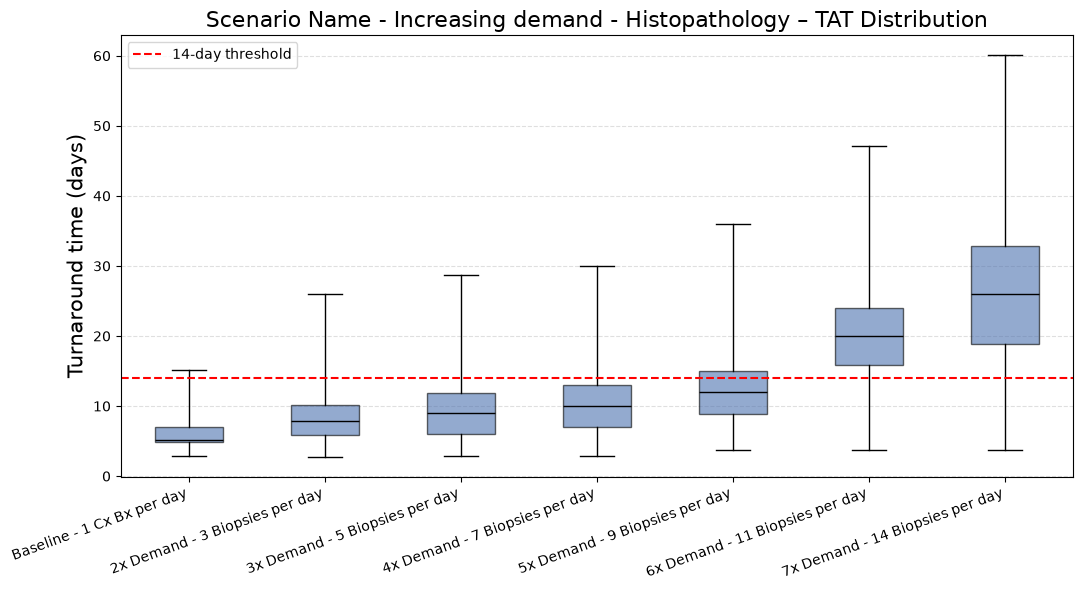

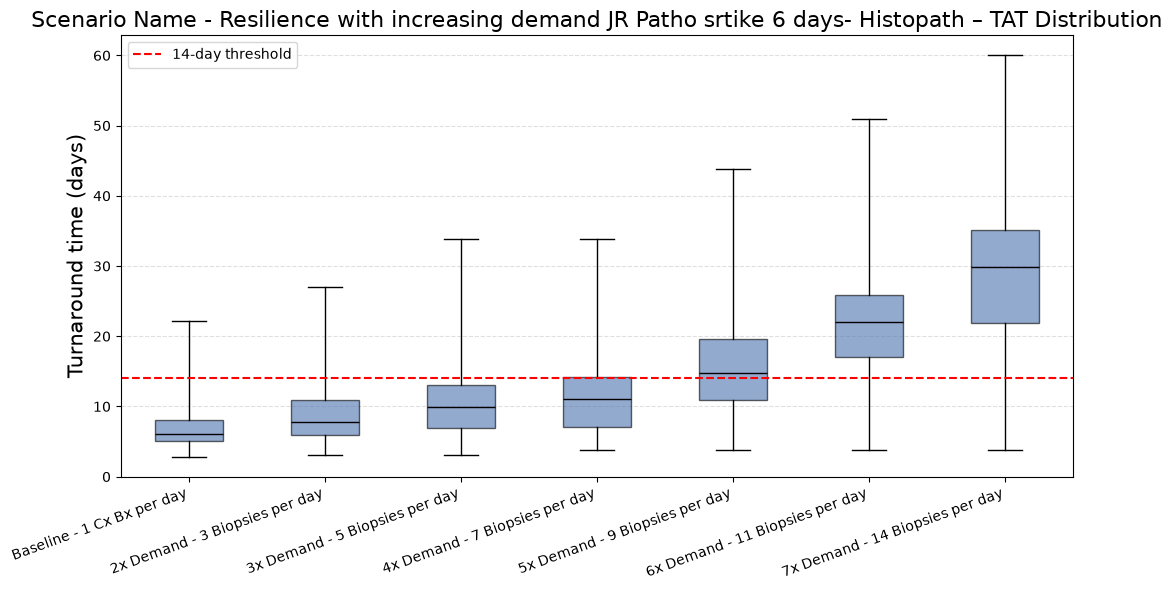

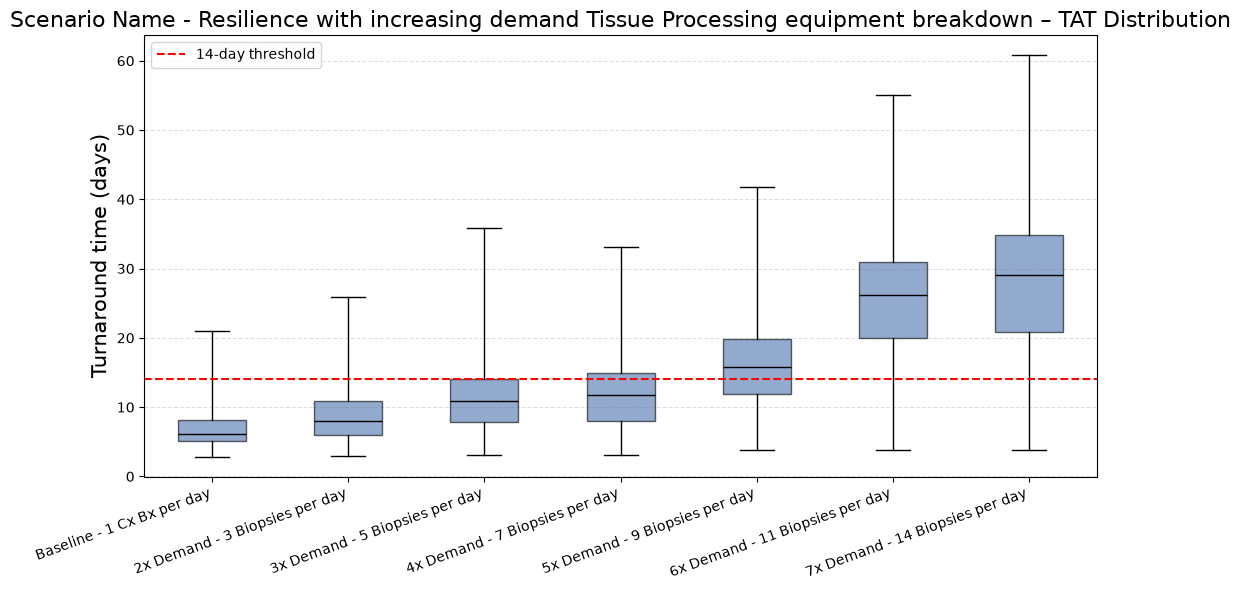

In [18]:
for title, block in experiments:
    plot_tat_boxplot(title, block, figsize=(11, 6))
    plt.show()


## TAT vs Resource Utilisation

For each pathway the TAT box plot (outcome) is stacked above a resource-utilisation
heatmap (driver), sharing the demand-scenario x-axis. Heatmap colour is centred at
100% so red = at/over capacity. Scenarios are aligned by position between the two
files (labels differ slightly); resources with no reported utilisation are dropped.


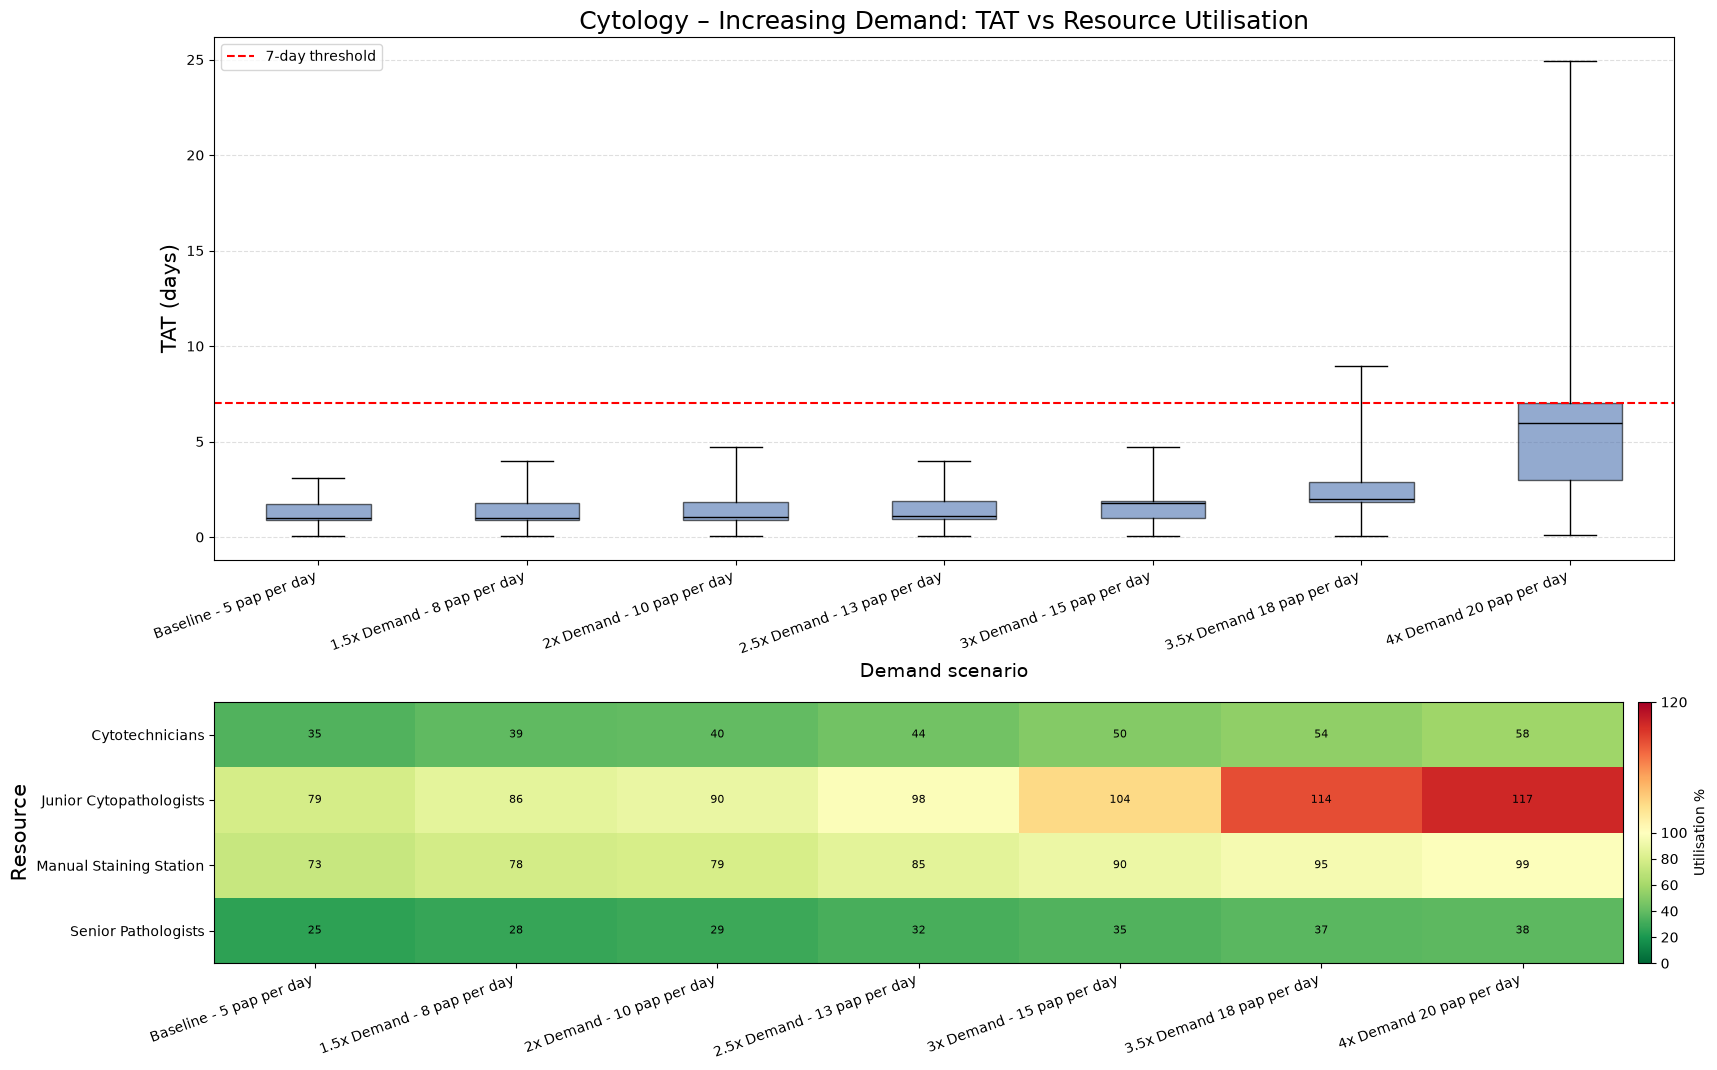

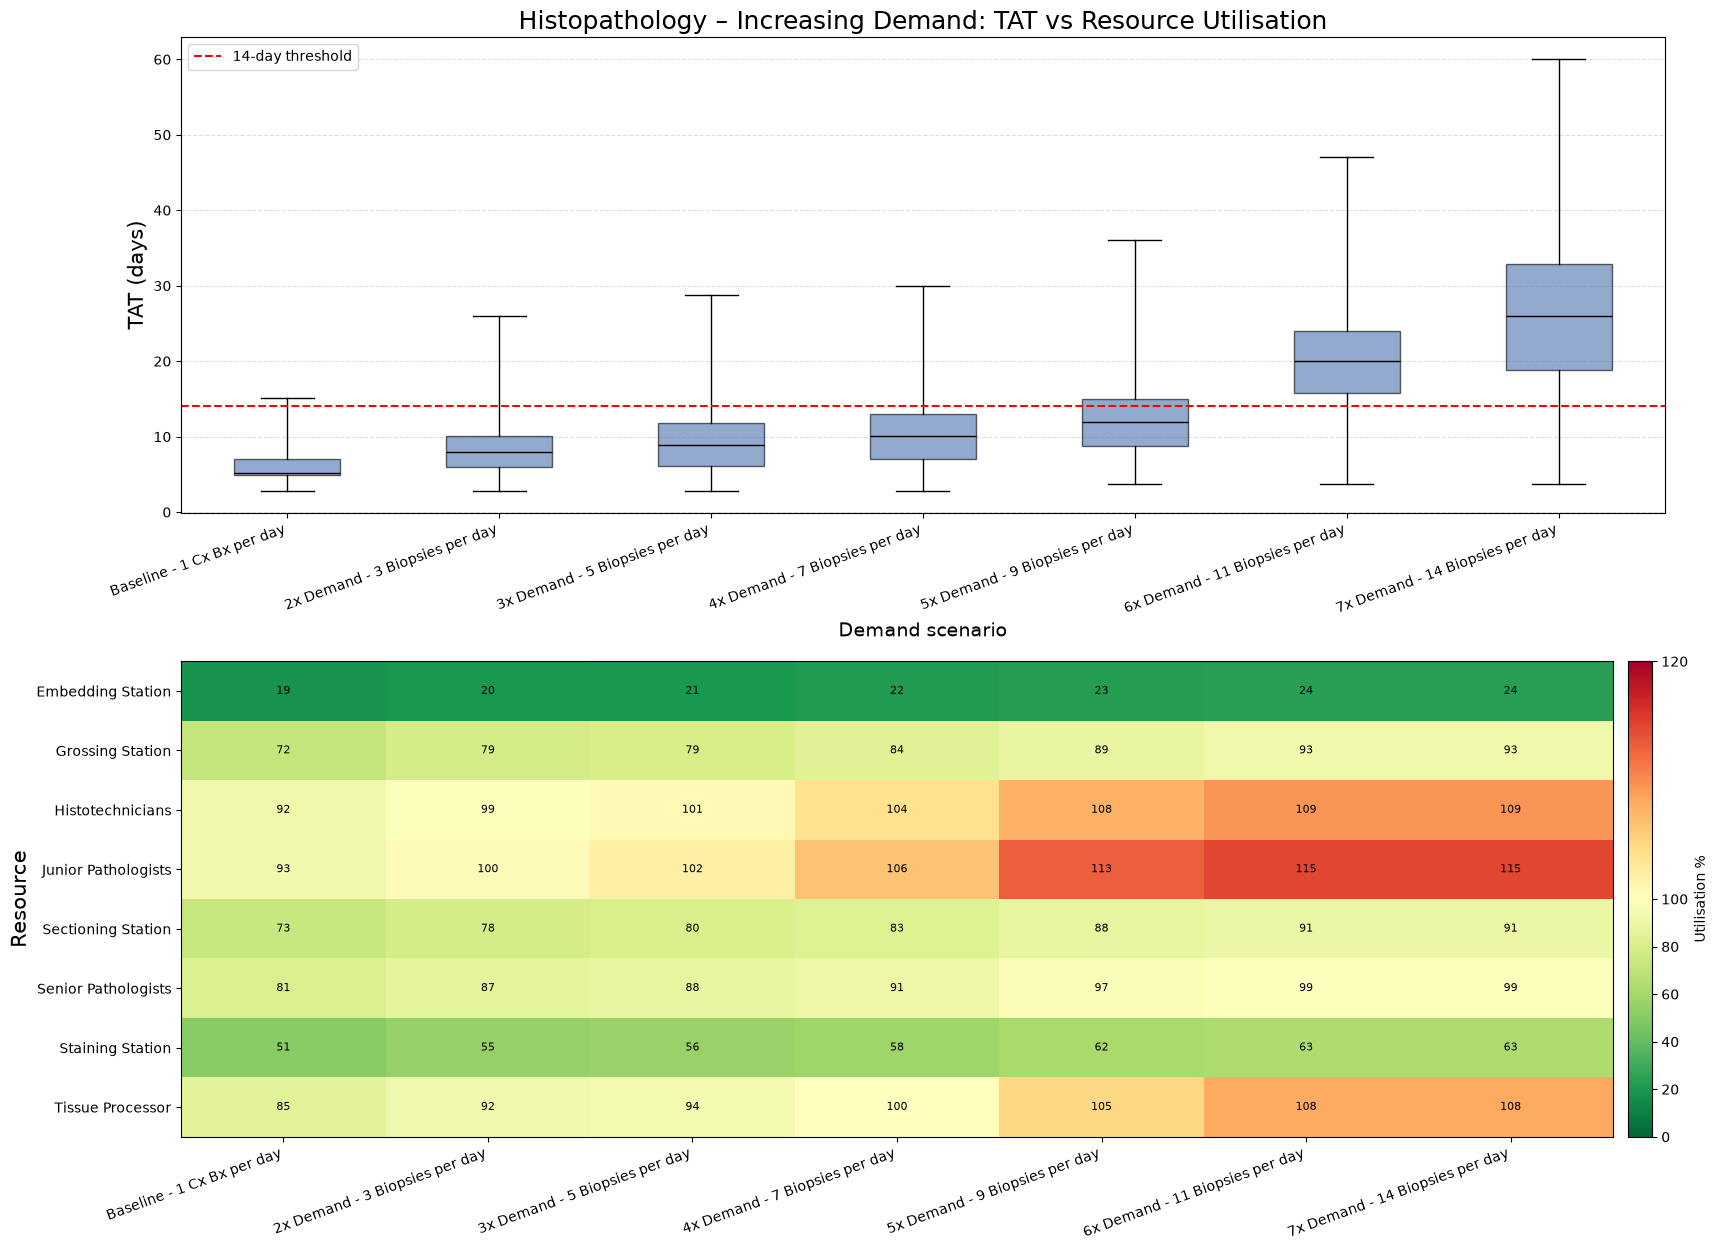

In [ ]:
def load_util_blocks(u):
    """Split utilisation file into per-scenario blocks: {label, {resource: pct}}."""
    blocks, current = [], None
    for _, row in u.iterrows():
        key = str(row["utilisation_key"]).strip()
        rname = row["resource_name"]
        if pd.isna(rname):
            if key and key.lower() != "nan" and "utilisation percentages" not in key.lower():
                current = {"label": key, "res": {}}
                blocks.append(current)
            continue
        if current is not None:
            current["res"][str(rname).strip()] = pd.to_numeric(
                row["utilisation_pct"], errors="coerce"
            )
    return blocks


CYTO_MARKERS = {"Cytotechnicians", "Junior Cytopathologists"}
HISTO_MARKERS = {
    "Histotechnicians", "Tissue Processor", "Embedding Station",
    "Sectioning Station", "Grossing Station",
}


def pathway_of(block):
    res = set(block["res"])
    if res & CYTO_MARKERS:
        return "cyto"
    if res & HISTO_MARKERS:
        return "histo"
    return None


def util_matrix(blocks):
    """Return (resources, scenarios, matrix[resource, scenario]), dropping all-NaN resources."""
    scenarios = [b["label"] for b in blocks]
    resources = []
    for b in blocks:
        for r in b["res"]:
            if r not in resources:
                resources.append(r)
    mat = np.full((len(resources), len(scenarios)), np.nan)
    for j, b in enumerate(blocks):
        for i, r in enumerate(resources):
            mat[i, j] = b["res"].get(r, np.nan)
    keep = ~np.all(np.isnan(mat), axis=1)
    return [r for r, k in zip(resources, keep) if k], scenarios, mat[keep]


util_blocks = load_util_blocks(df_res_util)
cyto_blocks = [b for b in util_blocks if pathway_of(b) == "cyto"]
histo_blocks = [b for b in util_blocks if pathway_of(b) == "histo"]
tat_by_title = {t: b for t, b in experiments}

pairs = [
    ("Cytology – Increasing Demand", "Scenario Name - Increasing Demand", cyto_blocks, 7),
    (
        "Histopathology – Increasing Demand",
        "Scenario Name - Increasing demand - Histopathology",
        histo_blocks,
        14,
    ),
]

for pname, tat_title, ublocks, threshold in pairs:
    box_stats = build_box_stats(tat_by_title[tat_title])
    resources, scenarios, mat = util_matrix(ublocks)
    n = len(scenarios)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True,
        figsize=(1.9 * n + 4, 0.45 * len(resources) + 9),
        gridspec_kw={"height_ratios": [4, max(2.0, 0.5 * len(resources))]},
    )

    ax_top.bxp(
        box_stats, showmeans=False, patch_artist=True,
        boxprops=dict(facecolor="#4C72B0", alpha=0.6),
        medianprops=dict(color="black"),
    )
    ax_top.axhline(
        threshold, color="red", linestyle="--", linewidth=1.5,
        label=f"{threshold}-day threshold",
    )
    ax_top.legend(loc="upper left")
    ax_top.set_ylabel("TAT (days)", fontsize=15)
    ax_top.set_title(f"{pname}: TAT vs Resource Utilisation", fontsize=18)
    ax_top.grid(axis="y", linestyle="--", alpha=0.4)
    ax_top.set_xticks(range(1, n + 1))
    ax_top.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax_top.tick_params(axis="x", labelbottom=True)
    ax_top.set_xlabel("Demand scenario", fontsize=14)

    norm = TwoSlopeNorm(vmin=0, vcenter=100, vmax=max(120, np.nanmax(mat)))
    cmap = plt.cm.RdYlGn_r.copy()
    cmap.set_bad("#e6e6e6")
    im = ax_bot.imshow(
        np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, norm=norm,
        extent=(0.5, n + 0.5, len(resources) - 0.5, -0.5),
    )
    for i in range(len(resources)):
        for j in range(n):
            v = mat[i, j]
            if not np.isnan(v):
                ax_bot.text(j + 1, i, f"{v:.0f}", ha="center", va="center", fontsize=8)

    ax_bot.set_yticks(range(len(resources)))
    ax_bot.set_yticklabels(resources)
    ax_bot.set_xticks(range(1, n + 1))
    ax_bot.set_xticklabels([s["label"] for s in box_stats], rotation=20, ha="right")
    ax_bot.set_xlim(0.5, n + 0.5)
    ax_bot.set_ylabel("Resource", fontsize=15)
    cbar = fig.colorbar(im, ax=ax_bot, orientation="vertical", fraction=0.025, pad=0.01)
    cbar.set_label("Utilisation %")
    plt.tight_layout()
    plt.show()


## Resilience Experiments

Bar plots of **Recovery Days** for every experiment block with non-empty Recovery Days
(JR Pathologist strike – cytology; JR Pathologist strike – histopathology;
Tissue Processing equipment breakdown). Infinite recovery (`inf` = never recovered
within the simulation horizon) is drawn as a tall hatched bar and labelled ∞.


Found 3 resilience experiment(s):
  - Resilience metric - JR Patho Strike with increasing demand - Cyto (7 scenarios)
  - Scenario Name - Resilience with increasing demand JR Patho srtike 6 days- Histopath (7 scenarios)
  - Scenario Name - Resilience with increasing demand Tissue Processing equipment breakdown (7 scenarios)


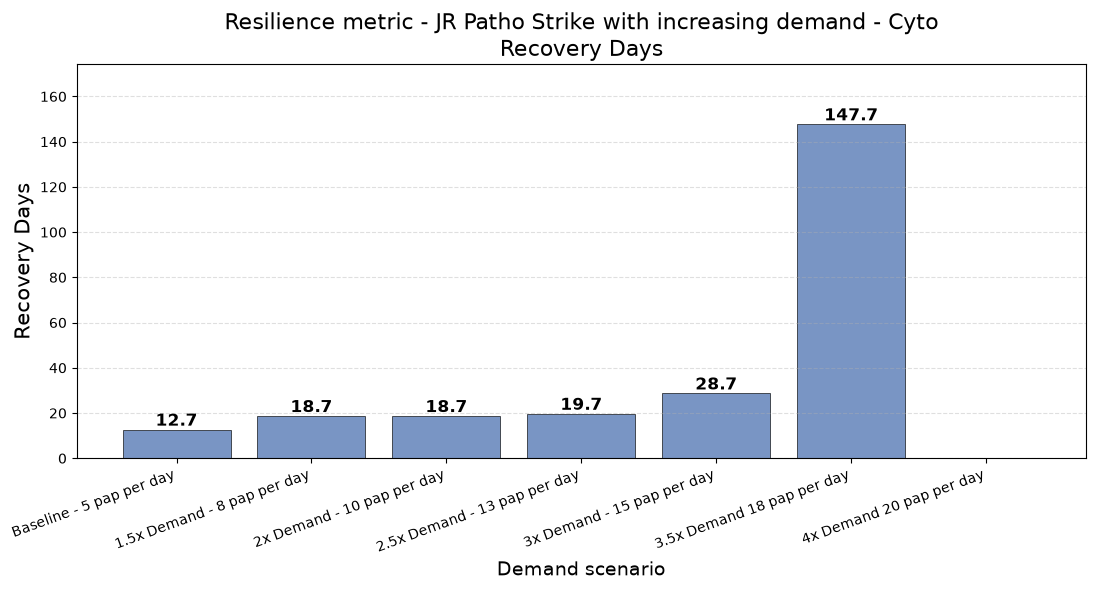

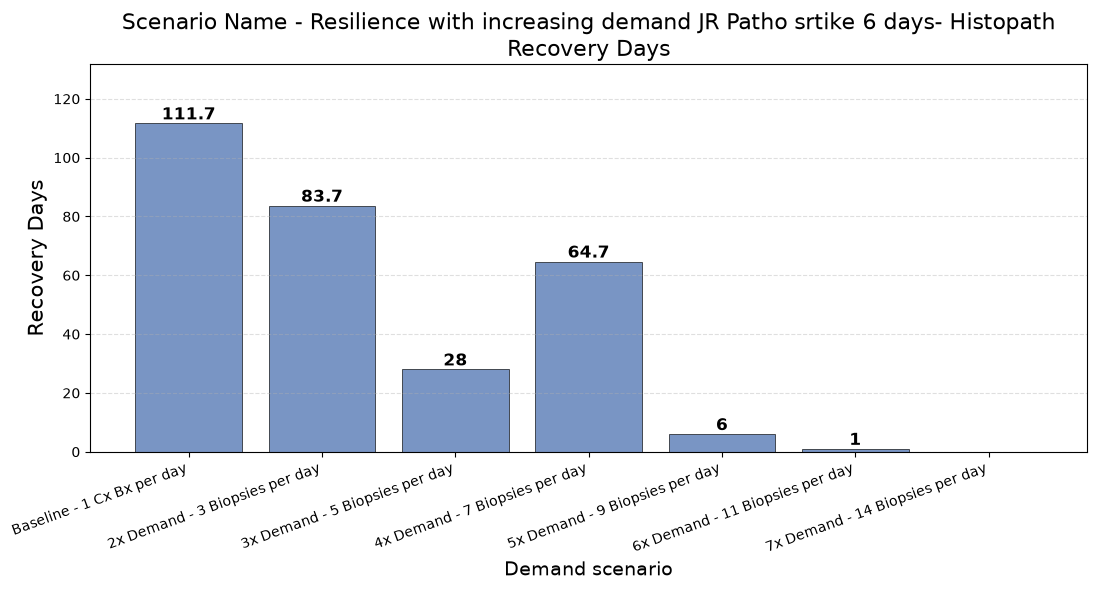

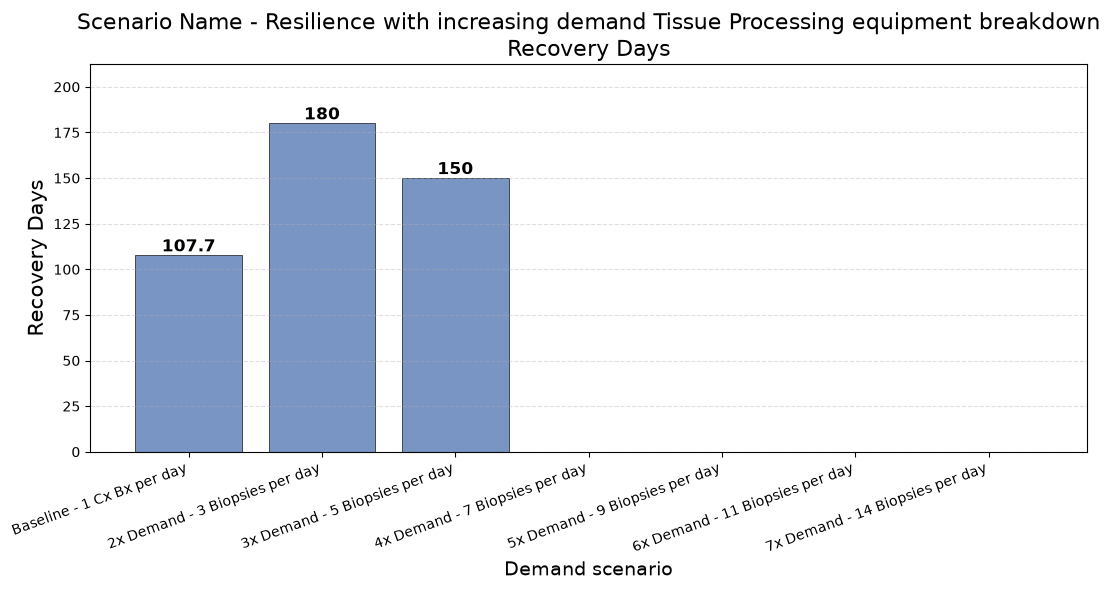

In [ ]:
resilience = [
    (title, block)
    for title, block in experiments
    if block["Recovery Days"].notna().any()
]

print(f"Found {len(resilience)} resilience experiment(s):")
for title, block in resilience:
    print(f"  - {title} ({len(block)} scenarios)")

for title, block in resilience:
    labels = block[LABEL_COL].astype(str).str.strip().tolist()
    recovery = block["Recovery Days"].to_numpy(dtype=float)

    finite = recovery[np.isfinite(recovery)]
    max_finite = float(np.max(finite)) if len(finite) else 10.0
    display_heights = np.where(np.isinf(recovery), max_finite * 1.25, recovery)
    display_heights = np.nan_to_num(display_heights, nan=0.0)

    fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(labels)), 6))
    bars = ax.bar(
        range(len(labels)),
        display_heights,
        color="#4C72B0",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.6,
    )

    for bar, v in zip(bars, recovery):
        if np.isinf(v):
            bar.set_hatch("//")
            bar.set_facecolor("#c44e52")
            bar.set_alpha(0.85)

    for bar, v in zip(bars, recovery):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            format_recovery(v),
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#c44e52" if np.isinf(v) else "black",
        )

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Recovery Days", fontsize=15)
    ax.set_xlabel("Demand scenario", fontsize=14)
    ax.set_title(f"{title}\nRecovery Days", fontsize=16)
    ax.set_ylim(0, max(display_heights) * 1.18)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
